# Modeling and evaluation

The objective is to classify whether a bank client subscribes to a term deposit while giving appropriate attention to the minority `yes` class. The candidate models are balanced logistic regression, balanced decision tree, normal random forest, balanced SVM, and a soft-voting ensemble built from the tuned component pipelines.

Final model comparison uses five-fold stratified cross-validation on the training data only. The primary reported measures are F1-score and scikit-learn's `average_precision` score. F1 balances precision and recall at the model's classification threshold; average precision summarizes the precision-recall relationship over score thresholds and should not be treated as identical to every trapezoidal PR-AUC implementation.

The notebook also evaluates the selected candidates on the test set, displays confusion matrices, and plots precision-recall curves from continuous positive-class scores. These test results were inspected during development, so the test set was not a completely untouched final holdout.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../data/bank/bank-full.csv', sep=';')


In [8]:
X = df.drop('y', axis=1)
y = df['y']

In [9]:
import sys

if '..' not in sys.path:
    sys.path.append('..')

from src import model_config



In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Convert target variables from strings to integers
y_train = y_train.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})

In [12]:
X_train.shape

(36168, 16)

In [13]:
X_test.shape

(9043, 16)

In [14]:
y_train.shape

(36168,)

In [15]:
y_test.shape

(9043,)

In [16]:
print("Training set proportions:\n", y_train.value_counts(normalize=True))
print("\nTest set proportions:\n", y_test.value_counts(normalize=True))

Training set proportions:
 y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Test set proportions:
 y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [17]:
from src.model_config import get_model_pipelines

pipelines = get_model_pipelines(X_train)

In [18]:
len(pipelines)

10

In [19]:
pipelines.keys()

dict_keys(['decision_tree_normal', 'decision_tree_balanced', 'logistic_regression_normal', 'logistic_regression_balanced', 'random_forest_normal', 'random_forest_balanced', 'svm_normal', 'svm_balanced', 'voting_ensemble_normal', 'voting_ensemble_balanced'])

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}

results = []

for name, pipeline in pipelines.items():
    
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    
    mean_f1 = np.mean(cv_scores['test_f1'])
    std_f1 = np.std(cv_scores['test_f1'])
    mean_pr_auc = np.mean(cv_scores['test_pr_auc'])
    
    results.append({
        'Pipeline Name': name,
        'Mean CV F1': mean_f1,
        'Std CV F1': std_f1,
        'Mean CV PR-AUC': mean_pr_auc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='Mean CV F1', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)


results_df

,Pipeline Name,Mean CV F1,Std CV F1,Mean CV PR-AUC
0,random_forest_balanced,0.427883,0.014986,0.415484
1,voting_ensemble_balanced,0.393223,0.008507,0.421876
2,logistic_regression_balanced,0.372822,0.003512,0.398151
3,random_forest_normal,0.318793,0.016373,0.422028
4,decision_tree_balanced,0.304675,0.007322,0.173935
5,decision_tree_normal,0.299087,0.021897,0.170252
6,logistic_regression_normal,0.274874,0.012208,0.401805
7,svm_balanced,0.271372,0.012426,0.252292
8,voting_ensemble_normal,0.180804,0.048231,0.432346
9,svm_normal,0.000000,0.000000,0.302847


In [22]:
print(results_df)

                  Pipeline Name  Mean CV F1  Std CV F1  Mean CV PR-AUC
0        random_forest_balanced    0.427883   0.014986        0.415484
1      voting_ensemble_balanced    0.393223   0.008507        0.421876
2  logistic_regression_balanced    0.372822   0.003512        0.398151
3          random_forest_normal    0.318793   0.016373        0.422028
4        decision_tree_balanced    0.304675   0.007322        0.173935
5          decision_tree_normal    0.299087   0.021897        0.170252
6    logistic_regression_normal    0.274874   0.012208        0.401805
7                  svm_balanced    0.271372   0.012426        0.252292
8        voting_ensemble_normal    0.180804   0.048231        0.432346
9                    svm_normal    0.000000   0.000000        0.302847


In [23]:
from sklearn.metrics import precision_score, recall_score

precision_recall_results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    precision_recall_results.append({
        'Pipeline Name': name,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0)
    })

precision_recall_df = pd.DataFrame(precision_recall_results)
precision_recall_df.sort_values(by='Recall', ascending=False, inplace=True)
precision_recall_df.reset_index(drop=True, inplace=True)

precision_recall_df

c:\Users\M T Sulthana\OneDrive\Desktop\ml project 1\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\M T Sulthana\OneDrive\Desktop\ml project 1\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Pipeline Name,Precision,Recall
0,logistic_regression_balanced,0.267828,0.624764
1,random_forest_balanced,0.479580,0.388469
2,voting_ensemble_balanced,0.553055,0.325142
3,decision_tree_normal,0.273393,0.317580
4,decision_tree_balanced,0.319336,0.309074
5,svm_balanced,0.313109,0.273157
6,random_forest_normal,0.651934,0.223062
7,logistic_regression_normal,0.666667,0.177694
8,voting_ensemble_normal,0.725389,0.132325
9,svm_normal,0.000000,0.000000


In [24]:
from sklearn.metrics import confusion_matrix

confusion_matrices = {}

for name in ['random_forest_normal', 'random_forest_balanced']:
    pipeline = pipelines[name]
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    confusion_matrices[name] = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=[0, 1]),
        index=['Actual 0', 'Actual 1'],
        columns=['Predicted 0', 'Predicted 1']
    )

confusion_matrix_df = pd.concat(confusion_matrices, names=['Model'])
confusion_matrix_df

Predicted 0  Predicted 1
Model                                                    
random_forest_normal   Actual 0         7859          126
                       Actual 1          822          236
random_forest_balanced Actual 0         7539          446
                       Actual 1          647          411

In [25]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

balanced_logistic_pipeline = clone(pipelines['logistic_regression_balanced'])

logistic_c_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

logistic_grid_search = GridSearchCV(
    estimator=balanced_logistic_pipeline,
    param_grid=logistic_c_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    
    refit=True,
    return_train_score=False
)

logistic_grid_search.fit(X_train, y_train)

logistic_c_results = pd.DataFrame(logistic_grid_search.cv_results_)[[
    'param_model__C',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].rename(columns={
    'param_model__C': 'C',
    'mean_test_score': 'Mean CV F1',
    'std_test_score': 'Std CV F1',
    'rank_test_score': 'Rank'
}).sort_values('C')

print(f"Best C: {logistic_grid_search.best_params_['model__C']}")
print(f"Best mean CV F1: {logistic_grid_search.best_score_:.6f}")
logistic_c_results

Best C: 100.0
Best mean CV F1: 0.372850


,C,Mean CV F1,Std CV F1,Rank
0,0.01,0.366736,0.005189,5
1,0.10,0.371881,0.004388,4
2,1.00,0.372822,0.003512,2
3,10.00,0.372819,0.003472,3
4,100.00,0.372850,0.003809,1


In [26]:
balanced_svm_pipeline = clone(pipelines['svm_balanced'])

# Small exponential grid: 3 values for each hyperparameter (9 combinations).
svm_param_grid = {
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': [0.001, 0.01, 0.1]
}

svm_grid_search = GridSearchCV(
    estimator=balanced_svm_pipeline,
    param_grid=svm_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

# The test set is not used here; it remains untouched for final evaluation.
svm_grid_search.fit(X_train, y_train)

svm_results = pd.DataFrame(svm_grid_search.cv_results_)[[
    'param_model__C',
    'param_model__gamma',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].rename(columns={
    'param_model__C': 'C',
    'param_model__gamma': 'gamma',
    'mean_test_score': 'Mean CV F1',
    'std_test_score': 'Std CV F1',
    'rank_test_score': 'Rank'
}).sort_values(['Rank', 'C', 'gamma'])

print(f"Best parameters: {svm_grid_search.best_params_}")
print(f"Best mean CV F1: {svm_grid_search.best_score_:.6f}")
svm_results

c:\Users\M T Sulthana\OneDrive\Desktop\ml project 1\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best parameters: {'model__C': 10.0, 'model__gamma': 0.01}
Best mean CV F1: 0.407847


,C,gamma,Mean CV F1,Std CV F1,Rank
7,10.0,0.010,0.407847,0.005842,1
5,1.0,0.100,0.398504,0.012413,2
4,1.0,0.010,0.374685,0.012303,3
3,1.0,0.001,0.372293,0.014092,4
6,10.0,0.001,0.369969,0.006634,5
1,0.1,0.010,0.367745,0.013735,6
2,0.1,0.100,0.365193,0.008995,7
8,10.0,0.100,0.351627,0.011304,8
0,0.1,0.001,0.310812,0.007009,9


In [27]:
balanced_tree_pipeline = clone(pipelines['decision_tree_balanced'])

# Five reasonable tree depths, from a shallow to a deeper tree.
tree_param_grid = {
    'model__max_depth': [3, 5, 10, 20, 30]
}

tree_grid_search = GridSearchCV(
    estimator=balanced_tree_pipeline,
    param_grid=tree_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

# The test set remains untouched during tuning.
tree_grid_search.fit(X_train, y_train)

tree_results = pd.DataFrame(tree_grid_search.cv_results_)[[
    'param_model__max_depth',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].rename(columns={
    'param_model__max_depth': 'max_depth',
    'mean_test_score': 'Mean CV F1',
    'std_test_score': 'Std CV F1',
    'rank_test_score': 'Rank'
}).sort_values('max_depth')

print(f"Best max_depth: {tree_grid_search.best_params_['model__max_depth']}")
print(f"Best mean CV F1: {tree_grid_search.best_score_:.6f}")
tree_results

Best max_depth: 10
Best mean CV F1: 0.410056


,max_depth,Mean CV F1,Std CV F1,Rank
0,3,0.311169,0.004971,5
1,5,0.379790,0.011373,2
2,10,0.410056,0.023734,1
3,20,0.337024,0.011355,3
4,30,0.322576,0.009954,4


In [28]:
normal_forest_pipeline = clone(pipelines['random_forest_normal'])
normal_forest_pipeline.set_params(model__n_estimators=300)

# Tune the normal random forest while keeping n_estimators fixed at 300.
forest_param_grid = {
    'model__max_depth': [5, 10, 15, 20, 30]
}

forest_grid_search = GridSearchCV(
    estimator=normal_forest_pipeline,
    param_grid=forest_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

# The test set remains untouched during tuning.
forest_grid_search.fit(X_train, y_train)

forest_results = pd.DataFrame(forest_grid_search.cv_results_)[[
    'param_model__max_depth',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].rename(columns={
    'param_model__max_depth': 'max_depth',
    'mean_test_score': 'Mean CV F1',
    'std_test_score': 'Std CV F1',
    'rank_test_score': 'Rank'
}).sort_values('max_depth')

print(f"Best max_depth: {forest_grid_search.best_params_['model__max_depth']}")
print(f"Best mean CV F1: {forest_grid_search.best_score_:.6f}")
forest_results

Best max_depth: 30
Best mean CV F1: 0.315658


,max_depth,Mean CV F1,Std CV F1,Rank
0,5,0.194346,0.017497,5
1,10,0.268355,0.010316,4
2,15,0.294815,0.010803,3
3,20,0.309707,0.014647,2
4,30,0.315658,0.020154,1


In [29]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

# Use the refitted best pipelines, including the normal random-forest candidate.
tuned_voting = VotingClassifier(
    estimators=[
        ('logistic_regression', clone(logistic_grid_search.best_estimator_)),
        ('decision_tree', clone(tree_grid_search.best_estimator_)),
        ('random_forest', clone(forest_grid_search.best_estimator_)),
        ('svm', clone(svm_grid_search.best_estimator_)),
    ],
    voting='soft',
    n_jobs=-1
)

# Calculate F1 using training-fold validation only; the test set is untouched.
tuned_voting_cv_f1 = cross_val_score(
    tuned_voting,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# Fit the ensemble on training data only; do not access the test set.
tuned_voting.fit(X_train, y_train)

print('Tuned voting ensemble fitted on training data only.')
print(f"Mean training CV F1: {tuned_voting_cv_f1.mean():.6f}")
print(f"Std training CV F1: {tuned_voting_cv_f1.std():.6f}")

Tuned voting ensemble fitted on training data only.
Mean training CV F1: 0.454514
Std training CV F1: 0.012473


In [30]:
from sklearn.model_selection import cross_validate

final_candidate_models = {
    'logistic_regression_balanced_tuned': logistic_grid_search.best_estimator_,
    'decision_tree_balanced_tuned': tree_grid_search.best_estimator_,
    'random_forest_normal_tuned': forest_grid_search.best_estimator_,
    'svm_balanced_tuned': svm_grid_search.best_estimator_,
    'voting_ensemble_balanced_tuned': tuned_voting,
}

final_cv_scoring = {
    'f1': 'f1',
    'pr_auc': 'average_precision',
}

final_cv_results = []

# Final comparison uses training data and cross-validation only; no test data is used.
for model_name, model in final_candidate_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=final_cv_scoring,
        n_jobs=-1,
        error_score='raise',
    )

    final_cv_results.append({
        'Model': model_name,
        'Mean CV F1': scores['test_f1'].mean(),
        'Std CV F1': scores['test_f1'].std(),
        'Mean CV PR-AUC': scores['test_pr_auc'].mean(),
        'Std CV PR-AUC': scores['test_pr_auc'].std(),
    })

final_cv_comparison = pd.DataFrame(final_cv_results).sort_values(
    'Mean CV F1',
    ascending=False,
).reset_index(drop=True)

final_cv_comparison

,Model,Mean CV F1,Std CV F1,Mean CV PR-AUC,Std CV PR-AUC
0,voting_ensemble_balanced_tuned,0.454514,0.012473,0.433307,0.008331
1,decision_tree_balanced_tuned,0.410056,0.023734,0.381897,0.018014
2,svm_balanced_tuned,0.407847,0.005842,0.360002,0.004911
3,logistic_regression_balanced_tuned,0.372850,0.003809,0.398059,0.007514
4,random_forest_normal_tuned,0.315658,0.020154,0.425630,0.015498


In [31]:
forest_grid_search.best_params_

{'model__max_depth': 30}

In [34]:
forest_grid_search.best_score_

np.float64(0.3156577060643563)

In [33]:
forest_results

,max_depth,Mean CV F1,Std CV F1,Rank
0,5,0.194346,0.017497,5
1,10,0.268355,0.010316,4
2,15,0.294815,0.010803,3
3,20,0.309707,0.014647,2
4,30,0.315658,0.020154,1


In [37]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

test_evaluation_results = []
test_confusion_matrices = {}

# Evaluate the already selected models once on the held-out test set.
for model_name, model in final_candidate_models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_positive_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_positive_score = model.decision_function(X_test)
    else:
        raise AttributeError(
            f"{model_name} has neither predict_proba nor decision_function."
        )

    test_evaluation_results.append({
        'Model': model_name,
        'Precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_positive_score),
        'PR-AUC (Average Precision)': average_precision_score(
            y_test,
            y_positive_score,
        ),
    })
    test_confusion_matrices[model_name] = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=[0, 1]),
        index=['Actual no', 'Actual yes'],
        columns=['Predicted no', 'Predicted yes'],
    )

test_evaluation_comparison = pd.DataFrame(test_evaluation_results).sort_values(
    'F1-score',
    ascending=False,
).reset_index(drop=True)

test_evaluation_comparison

,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision)
0,voting_ensemble_balanced_tuned,0.516058,0.440454,0.475268,0.794296,0.450399
1,decision_tree_balanced_tuned,0.347393,0.560491,0.428933,0.753873,0.385916
2,svm_balanced_tuned,0.334090,0.556711,0.417582,0.771081,0.376199
3,logistic_regression_balanced_tuned,0.267315,0.623819,0.374256,0.772193,0.409253
4,random_forest_normal_tuned,0.667590,0.227788,0.339676,0.792955,0.443972


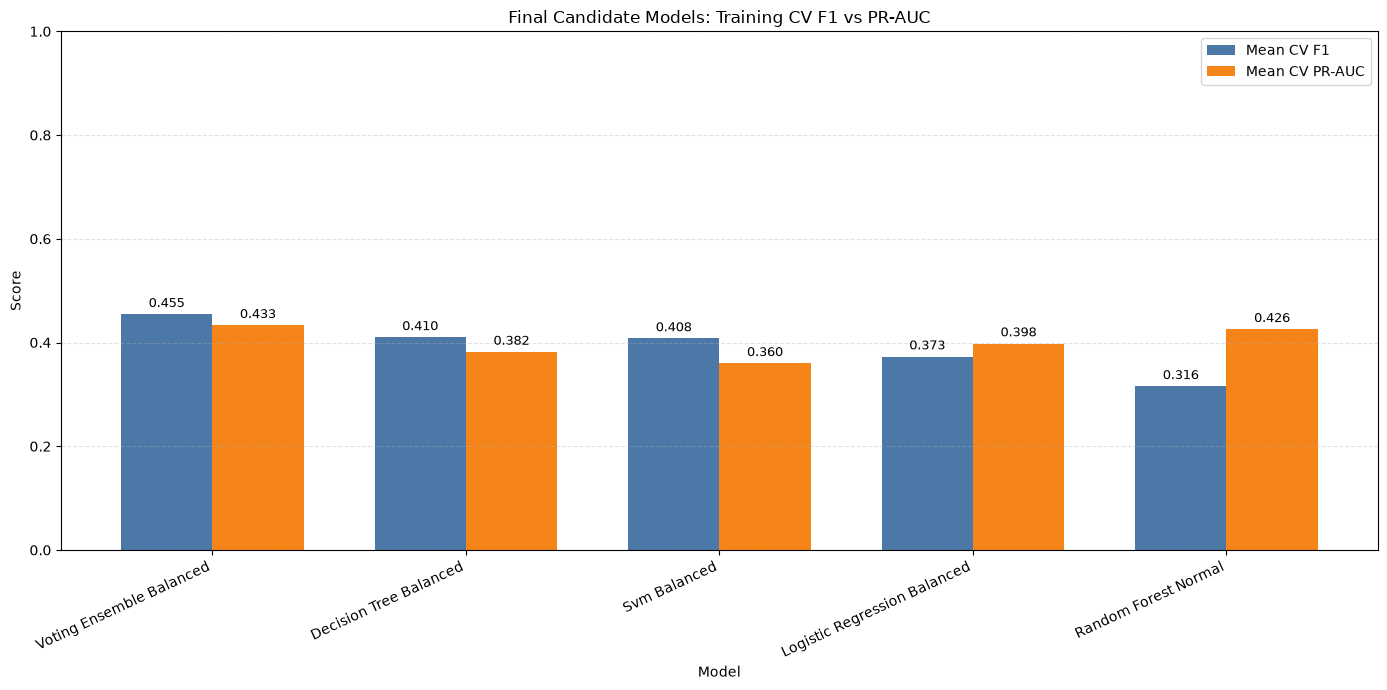

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = final_cv_comparison.copy()
plot_data['Model'] = plot_data['Model'].str.replace(
    '_tuned',
    '',
    regex=False,
).str.replace('_', ' ', regex=False).str.title()

x = np.arange(len(plot_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(14, 7))
f1_bars = ax.bar(
    x - bar_width / 2,
    plot_data['Mean CV F1'],
    bar_width,
    label='Mean CV F1',
    color='#4C78A8',
)
pr_auc_bars = ax.bar(
    x + bar_width / 2,
    plot_data['Mean CV PR-AUC'],
    bar_width,
    label='Mean CV PR-AUC',
    color='#F58518',
)

ax.set_title('Final Candidate Models: Training CV F1 vs PR-AUC')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(plot_data['Model'], rotation=25, ha='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend()

for bars in (f1_bars, pr_auc_bars):
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

fig.tight_layout()
plt.show()

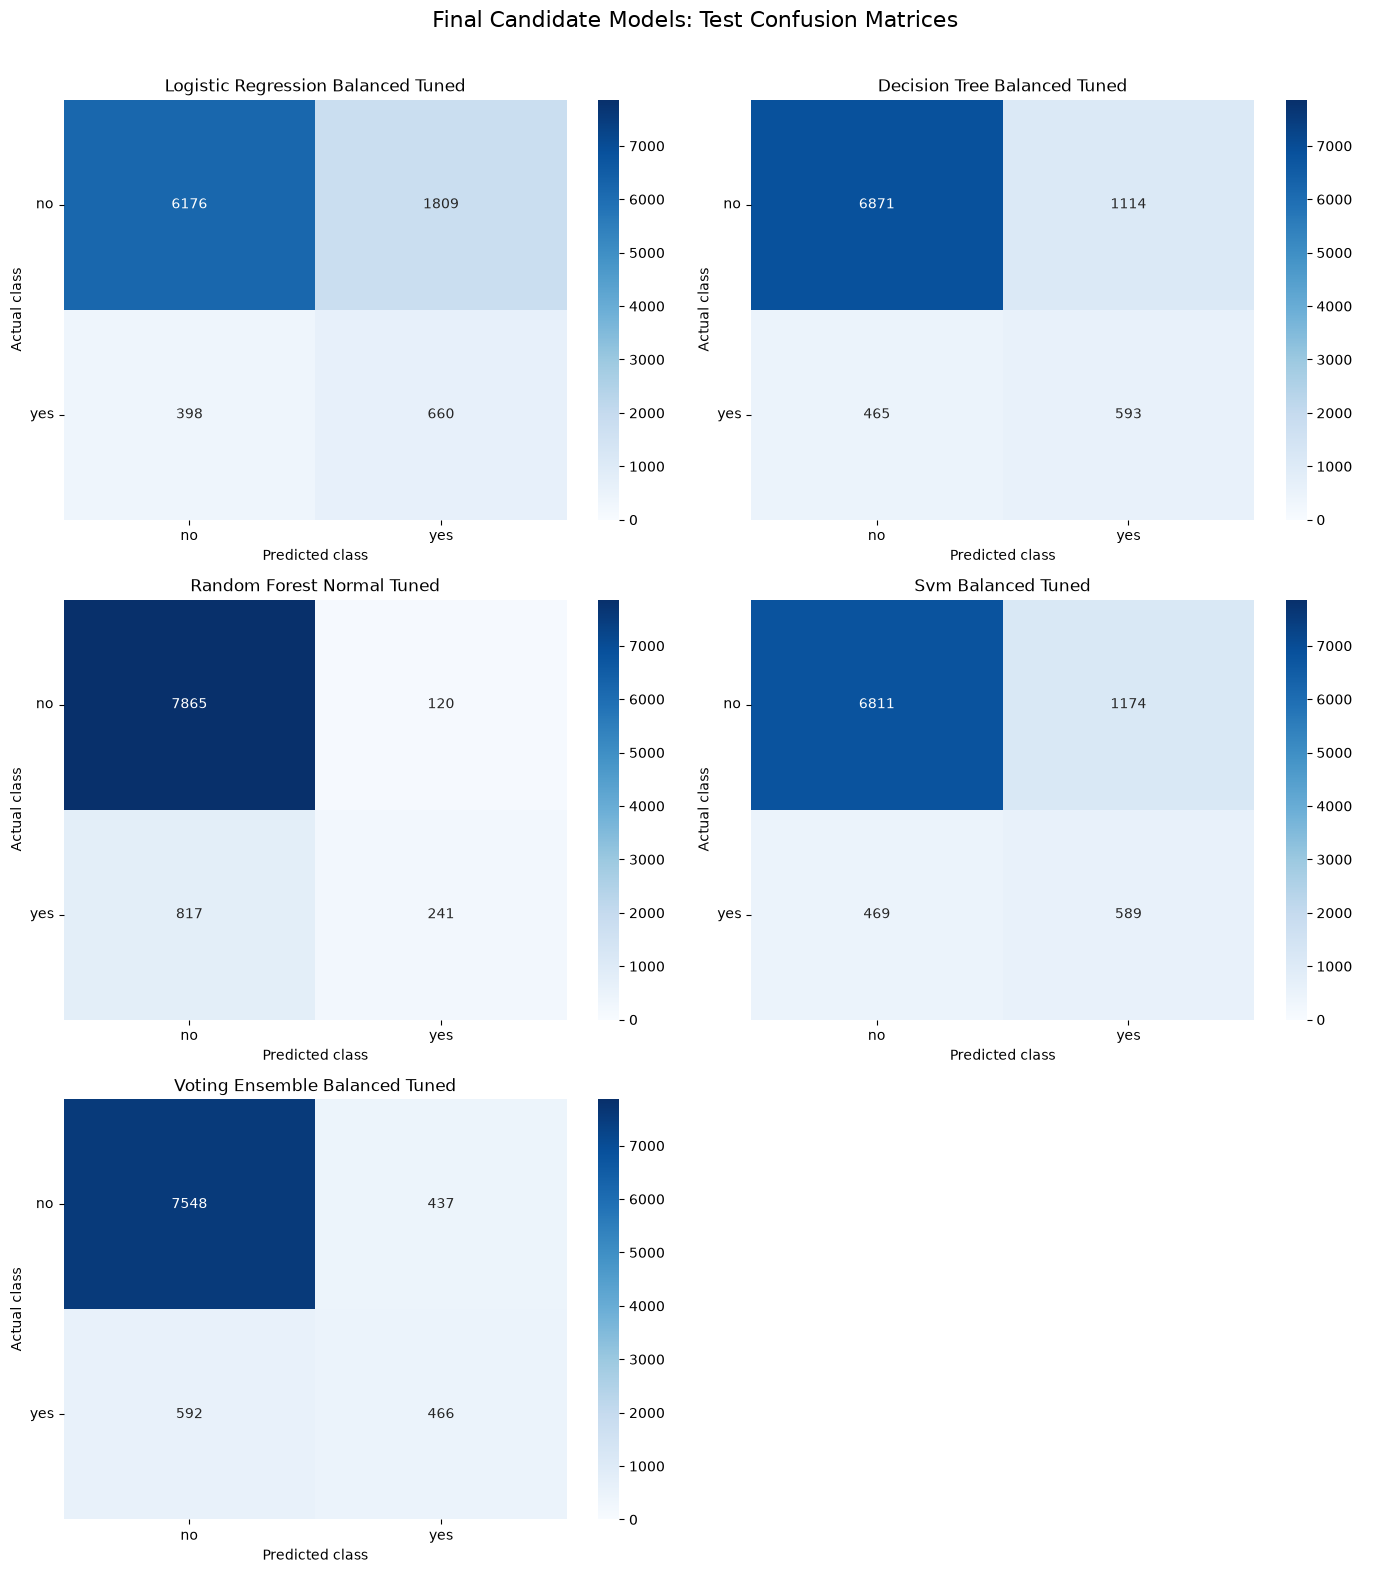

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = list(test_confusion_matrices)
confusion_matrix_values = [
    test_confusion_matrices[model_name].to_numpy()
    for model_name in model_names
]
color_scale_max = max(matrix.max() for matrix in confusion_matrix_values)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.ravel()

for axis, model_name, matrix in zip(axes, model_names, confusion_matrix_values):
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        vmin=0,
        vmax=color_scale_max,
        cbar=True,
        ax=axis,
    )
    axis.set_title(model_name.replace('_', ' ').title())
    axis.set_xlabel('Predicted class')
    axis.set_ylabel('Actual class')
    axis.set_xticklabels(['no', 'yes'])
    axis.set_yticklabels(['no', 'yes'], rotation=0)

axes[-1].axis('off')
fig.suptitle('Final Candidate Models: Test Confusion Matrices', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

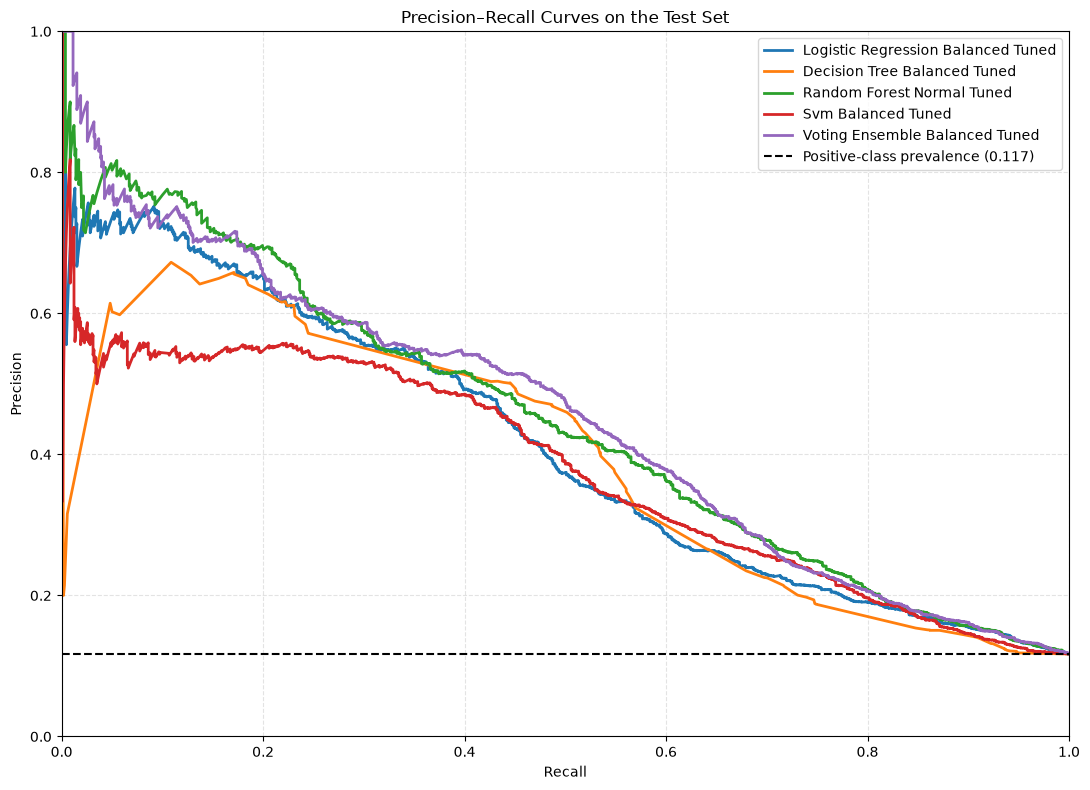

In [41]:
from sklearn.metrics import precision_recall_curve

test_positive_scores = {}
precision_recall_curves = {}
positive_class_prevalence = y_test.mean()

for model_name, model in final_candidate_models.items():
    if hasattr(model, 'predict_proba'):
        positive_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        positive_scores = model.decision_function(X_test)
    else:
        raise AttributeError(
            f"{model_name} has neither predict_proba nor decision_function."
        )

    test_positive_scores[model_name] = positive_scores
    precision, recall, _ = precision_recall_curve(y_test, positive_scores)
    precision_recall_curves[model_name] = (recall, precision)

fig, ax = plt.subplots(figsize=(11, 8))

for model_name, (recall, precision) in precision_recall_curves.items():
    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=model_name.replace('_', ' ').title(),
    )

ax.axhline(
    positive_class_prevalence,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Positive-class prevalence ({positive_class_prevalence:.3f})',
)
ax.set_title('Precision–Recall Curves on the Test Set')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

## Final comparison findings

The final training-only cross-validation comparison is summarized in the README using the stored `final_cv_comparison` output. In that comparison, the tuned voting ensemble has the highest mean CV F1 (0.454514) and mean CV average precision (0.433307). The normal random forest has the lowest mean CV F1 (0.315658) among the five candidates but a mean CV average precision of 0.425630. These are aggregate comparisons at the reported metrics, not claims that one model is best at every decision threshold.

The confusion matrices and precision-recall curves use the saved final test predictions and positive-class scores. They are descriptive test-set evaluations and should be interpreted together with the development-history limitation noted above.